Effective Signal Gain (26.3 dB)


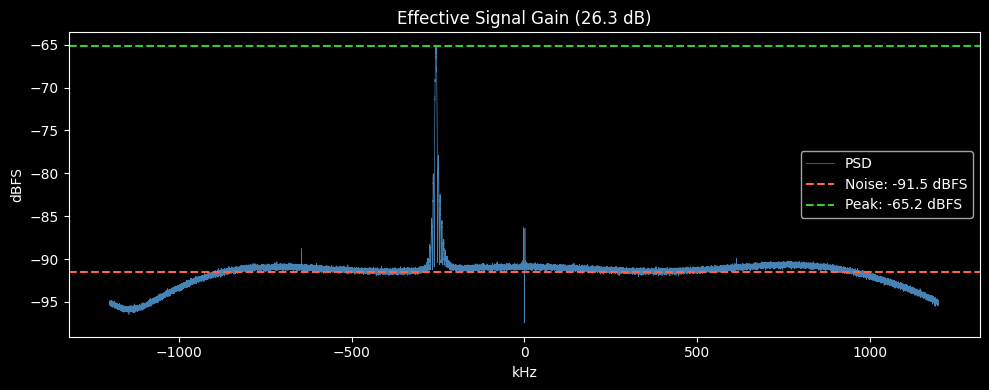

In [ ]:
#Effective Signal Gain

import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
from scipy.signal import welch

# Notebook Setup
%matplotlib inline
plt.style.use('dark_background')

# 1. Load Data
FILE = r'E:\Carry Chun\1_12-38-05_434400000Hz.wav'
data, fs = sf.read(FILE)
iq = data[:, 0] + 1j * data[:, 1]

# 2. DSP Analysis
f, psd = welch(iq, fs=fs, nperseg=65536, return_onesided=False)
f, psd = np.fft.fftshift(f), np.fft.fftshift(psd)
psd_db = 10 * np.log10(psd + 1e-30)

# Metrics
peak_pwr, peak_freq = np.max(psd_db), f[np.argmax(psd_db)]
noise_floor = np.median(np.sort(psd_db)[:int(0.6 * len(psd_db))])
snr_db = peak_pwr - noise_floor

# 3. Print Effective Signal Gain
print(f'Effective Signal Gain ({snr_db:.1f} dB)')

# 4. Visualization
plt.figure(figsize=(10, 4))
plt.plot(f / 1e3, psd_db, color='steelblue', lw=0.5, label='PSD')
plt.axhline(noise_floor, color='tomato', ls='--', label=f'Noise: {noise_floor:.1f} dBFS')
plt.axhline(peak_pwr, color='limegreen', ls='--', label=f'Peak: {peak_pwr:.1f} dBFS')

plt.title(f'Effective Signal Gain ({snr_db:.1f} dB)')
plt.xlabel('kHz'); plt.ylabel('dBFS'); plt.legend()
plt.tight_layout()
plt.show()